# Options order flow and intraday volatility
## Quick verification

This notebook checks the headline results in Tables 7, 11, 12 and 13 against the public aggregate files. Select **Runtime → Restart session and run all**. Allow 10 minutes to read the six steps; the calculations themselves take about a minute. You will see the four development contrasts, the final-window decision, matched reference errors, a Claims ledger and an execution receipt.

Inputs are 13 CSV files and one JSON file from the public repository release cited in the report. Step 1 checks every fingerprint. The [Extended walkthrough](https://colab.research.google.com/drive/1XhEt3VMt_wj7br8PRf3j88DTXFQhJ_rw) adds coverage, session distributions, subset diagnostics, availability cutoffs, placebo results and a second implementation. It regenerates Figures 5 to 8 and covers Tables 3, 6 to 14, 17 and 19.

### Terms used below

B0 contains price history; B1 adds **option state**; B2 adds the **mixed flow block**. Their cumulative predictor counts are 29, 69 and 138. H1 compares B1 with B0; H2 compares B2 with B1, within the same model family. Linear denotes the winsorised ridge model on log variance; Trees denotes LightGBM.

RV15 is realised variance over the next 15 minutes; RV30 and RV5 use 30 and 5 minutes. QLIKE is dimensionless: for observed variance y > 0 and forecast f > 0, L = y/f − log(y/f) − 1. Lower loss is better. A paired difference is baseline loss minus expanded-set loss; reduction (%) = 100 × mean difference / mean baseline loss. Loss reductions are forecast-error reductions, not returns.

A **session** is a market day; an **origin** is an eligible forecast time for an asset. The development window contains 419 sessions and 160,832 origins; the final window contains 25 sessions. In source columns, `primary` means development and `confirmation` means final; `log_ridge_harq` means Linear and `lightgbm_qlike` means Trees. `B1_over_B0` and `B2_over_B1` identify comparisons, not loss ratios. These definitions follow Table 4 and Table 22.


## Step 1: Verify inputs

The embedded package supplies every input. The checks validate the archive, the unique file names and every file fingerprint before any calculation.


In [1]:
# @title Step 1: Verify inputs
# Start an empty completion record for this run.
EXECUTED_CELLS = []
import base64, hashlib, io, json, sys, zipfile
from pathlib import Path
import pandas as pd
from IPython.display import display, HTML
import html
# Pin the public input bytes and the second implementation's expected digest.
SOURCE_COMMIT = '9b63302e2a9d1c8c43fb8755628f0e3dfc48ec03'
PUBLIC_SOURCE_COMMIT = '9b63302e2a9d1c8c43fb8755628f0e3dfc48ec03'
PUBLIC_HASHES = {'artifacts/rp4_v4_b4/primary_statistics.csv': '5c215fc38344839ecedea7b27f69efcb85fbefea84f1367d06229cb7407902d4', 'artifacts/rp4_v4_b2_rv15/session_losses.csv': '28174eb5a4f032d0b31b6a7b65e76e05710168278419d87bf31a92ebec2d9ac1', 'artifacts/rp4_v4_b4/coverage.csv': '67941d02647ae329fcc704a0b109949ab4312cb6915006302186b21770e853ef', 'artifacts/rp4_v4_b4/robustness.csv': '09925f9cefe4fcf2c19f4a915ad2994c125bbafdb94dfd332cc821ce1f180acb', 'artifacts/rp4_robustness_public_v1/reference_qlike.csv': 'af976a11074c144f024703c3d149a71103a6fde6bee11f7e43da64aeb19aacda', 'artifacts/rp4_robustness_public_v1/reference_contrasts.csv': '3e59dcbab5760464b0abf41ca2f748016e7d42a51542c195c3cee6687a2e862e', 'artifacts/rp4_robustness_public_v1/secondary_metrics.csv': '66ba437b3878bb4b2c5241863236b0eaf59712eaf3be8a63bbe40a1baca56f88', 'artifacts/rp4_robustness_public_v1/pit_60_contrasts.csv': '65cce2e2c23602249ce2eb1f1f00917729580689d14900134a59ded89bc0d698', 'artifacts/rp4_robustness_public_v1/pit_300_contrasts.csv': '976c95b896f9f2a836ee53a985e8462f7a6cfe2139690d66e264367f1ab78df4', 'artifacts/rp4_robustness_public_v1/placebo_log_ridge_harq_rv15_draws.csv': '3d5a8decdf511c04b225e49894b23f54996ea0ebfc6476f8d3ed4357469098c1', 'artifacts/rp4_robustness_public_v1/placebo_log_ridge_harq_rv30_draws.csv': '3e8b96c33e63d772f786555dfb948a170c970a49e3c490b22794570d0ac9ac8c', 'artifacts/rp4_v4_b4/volatility_regime_secondary.csv': '58a8ab77312256ab7b198f1b685b576e800d7619d6138476d16ba4c1e4b36494', 'artifacts/rp4_v4_b2_rv15/summary.json': '451e53869bb5f5058a635302bb08ad920ce11b8771fd2c6780545255b1ac25f4', 'artifacts/rp4_v4_b4/regime_secondary.csv': 'eb1fd165dd03f5c24efb717afdae7a30e04898dcd6fc53cb3172c1a2d81b03c7'}
BUNDLE_SHA256 = 'f3f82f184e585574b950ad4c65301fe57ae7e9853271275fbb875f083911b263'
CROSSCHECK_EXPECTED_DIGEST = 'db0fad77a1ce7b2bf2cfd33d4ffb47cef119219834ab76cd2ac02d5eea8c4cf2'
BUNDLE_BASE64 = '...'
# Validate the encoding and the complete archive before reading any input.
raw_bundle = base64.b64decode(BUNDLE_BASE64, validate=True)
assert hashlib.sha256(raw_bundle).hexdigest() == BUNDLE_SHA256
public_archive = zipfile.ZipFile(io.BytesIO(raw_bundle))
assert len(public_archive.namelist()) == len(set(public_archive.namelist())) == 14
assert set(public_archive.namelist()) == set(PUBLIC_HASHES)
# Every read checks the file fingerprint, including subsequent reads.
def fetch_bytes(path):
    raw = public_archive.read(path)
    assert hashlib.sha256(raw).hexdigest() == PUBLIC_HASHES[path], path
    return raw
for path in PUBLIC_HASHES:
    fetch_bytes(path)
manifest = pd.DataFrame([{'File':p.rsplit('/',1)[-1], 'Integrity':'Verified'} for p in PUBLIC_HASHES])
display(HTML('<h3>Inputs ready: 13 CSV files and one JSON file verified</h3>'))
display(manifest.style.hide(axis='index'))
hash_detail=''.join('<p><b>'+html.escape(p)+'</b><br><code>'+sha+'</code></p>' for p,sha in PUBLIC_HASHES.items())
display(HTML('<details><summary>Input fingerprints and source reference</summary><p>'+PUBLIC_SOURCE_COMMIT+'</p>'+hash_detail+'</details>'))
# Reject an empty table rather than continuing with missing results.
def read_public_csv(path):
    frame = pd.read_csv(io.BytesIO(fetch_bytes(path)))
    assert not frame.empty, path
    return frame
statistics = read_public_csv('artifacts/rp4_v4_b4/primary_statistics.csv')
losses = read_public_csv('artifacts/rp4_v4_b2_rv15/session_losses.csv')
summary = json.loads(fetch_bytes('artifacts/rp4_v4_b2_rv15/summary.json'))
# Labels are separate from the source identifiers used in every calculation.
families = {'log_ridge_harq':'Linear','lightgbm_qlike':'Trees'}

# Record that this step completed.
EXECUTED_CELLS.append('step_01_verify_inputs')


File,Integrity
primary_statistics.csv,Verified
session_losses.csv,Verified
coverage.csv,Verified
robustness.csv,Verified
reference_qlike.csv,Verified
reference_contrasts.csv,Verified
secondary_metrics.csv,Verified
pit_60_contrasts.csv,Verified
pit_300_contrasts.csv,Verified
placebo_log_ridge_harq_rv15_draws.csv,Verified


### Reading

These are the aggregate inputs described in Section 3.10 and used in Table 7. All input fingerprints must match before the first result is calculated.


## Step 2: The four primary contrasts

Verify the session counts, unique dates and finite losses. The calculation uses the already aggregated session losses; applying QLIKE to averaged targets and forecasts would change the estimand. The original checks require agreement within 1e-12 QLIKE and 1e-10 percentage points.


Four RV15 contrasts: arithmetic checks passed


,family,contrast,sessions,delta_QLIKE,reduction_percent,delta_error,check
0,log_ridge_harq,B1_over_B0,419,0.001616,0.880055,2.580401e-17,PASS: aggregates
1,log_ridge_harq,B2_over_B1,419,0.001134,0.622794,5.746272e-17,PASS: aggregates
2,lightgbm_qlike,B1_over_B0,419,0.002197,1.169969,3.989864e-17,PASS: aggregates
3,lightgbm_qlike,B2_over_B1,419,-0.000213,-0.114739,-6.155558e-17,PASS: aggregates


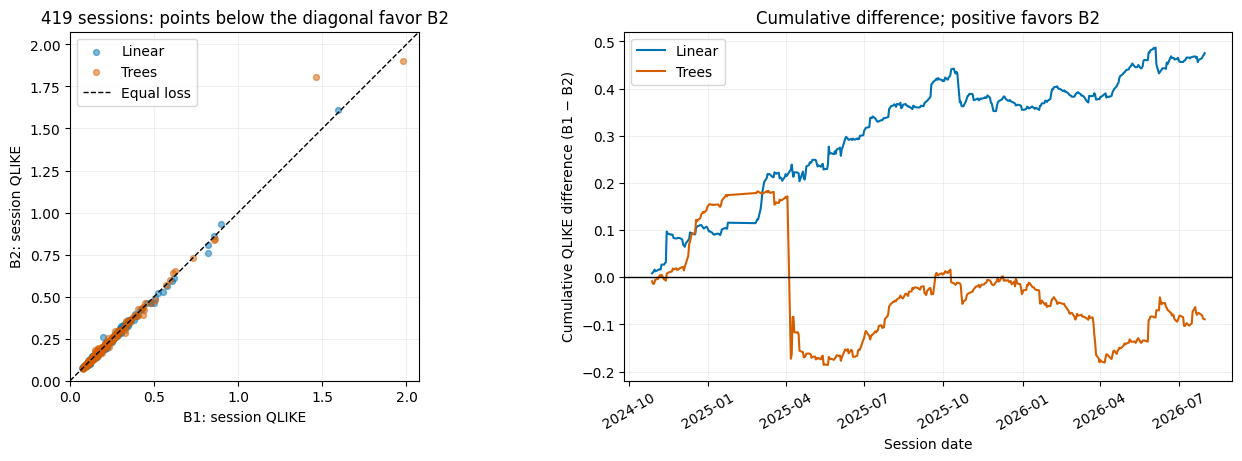

Matplotlib: 3.10.0
PASS: 0.880 / 0.623 / 1.170 / −0.115 %; primary_statistics.csv checks passed


In [2]:
# @title Step 2: The four primary contrasts
# Use math.fsum for accurate summation and Matplotlib for the figures.
import math

import matplotlib
import matplotlib.pyplot as plt


# Compare paired session losses with one published contrast.
def compare_saved(frame, row):
    """Reconcile one published contrast with paired session losses."""
    # Split the expanded and baseline information sets within each model family.
    expanded, baseline = row.contrast.split("_over_")
    base = frame[f"loss__{row.family}__{baseline}"]
    extra = frame[f"loss__{row.family}__{expanded}"]
    # Reject nonfinite losses and duplicate dates before taking means.
    if not all(math.isfinite(x) for x in [*base, *extra]):
        raise ValueError("Nonfinite losses.")
    if frame.session_date.nunique() != len(frame):
        raise ValueError("Duplicate sessions.")
    # Weight sessions equally; a positive difference favors the expanded model.
    mean_base = math.fsum(base) / len(base)
    delta = math.fsum(base - extra) / len(base)
    # Express the difference as a percentage of the mean baseline loss.
    percent = 100 * delta / mean_base
    # Check the count, mean, difference and percentage against explicit tolerances.
    assert len(frame) == row.N_sessions
    assert abs(mean_base - row.baseline_loss) <= 1e-12
    assert abs(delta - row.estimate) <= 1e-12
    assert abs(percent - row.qlike_reduction_percent) <= 1e-10
    # Return the computed values and their differences from the published values.
    return {"family": row.family, "contrast": row.contrast,
            "sessions": len(frame), "delta_QLIKE": delta,
            "reduction_percent": percent, "delta_error": delta - row.estimate,
            "check": "PASS: aggregates"}


# Select RV15 in the development window.
selected = statistics.loc[
    (statistics.horizon_minutes == 15) & (statistics.window == "primary")
]
# Recompute both contrasts in both model families.
checks = pd.DataFrame(compare_saved(losses, row)
                      for row in selected.itertuples())
assert len(checks) == 4
print("Four RV15 contrasts: arithmetic checks passed")
display(checks)

# Sort session dates before drawing the cumulative series.
ordered = losses.sort_values("session_date")
dates = pd.to_datetime(ordered.session_date)
# Plot paired losses and cumulative QLIKE differences in separate panels.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")
for family, label, color in [
    ("log_ridge_harq", "Linear", "#0072B2"),
    ("lightgbm_qlike", "Trees", "#D55E00"),
]:
    # Use the same dates for B1 and B2; each point is one session.
    base = ordered[f"loss__{family}__B1"]
    extra = ordered[f"loss__{family}__B2"]
    axes[0].scatter(base, extra, s=18, alpha=0.5, color=color, label=label)
    axes[1].plot(dates, (base - extra).cumsum(), color=color, label=label)
# Draw the equal-loss diagonal; points below it favor B2.
limit = max(axes[0].get_xlim()[1], axes[0].get_ylim()[1])
axes[0].plot([0, limit], [0, limit], "k--", linewidth=1, label="Equal loss")
axes[0].set(xlabel="B1: session QLIKE", ylabel="B2: session QLIKE",
            title="419 sessions: points below the diagonal favor B2",
            xlim=(0, limit), ylim=(0, limit), aspect="equal")
# Draw zero as the boundary between positive and negative cumulative differences.
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(xlabel="Session date", ylabel="Cumulative QLIKE difference (B1 − B2)",
            title="Cumulative difference; positive favors B2")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.2)
axes[1].tick_params(axis="x", rotation=30)
plt.show()
print("Matplotlib:", matplotlib.__version__)

# Check the reported percentages rounded to three decimal places.
expected_rounded = {('log_ridge_harq','B1_over_B0'):0.880,
                    ('log_ridge_harq','B2_over_B1'):0.623,
                    ('lightgbm_qlike','B1_over_B0'):1.170,
                    ('lightgbm_qlike','B2_over_B1'):-0.115}
# Match each percentage to its model family and contrast.
for row in checks.to_dict('records'):
    assert round(row['reduction_percent'],3) == expected_rounded[(row['family'],row['contrast'])]
print('PASS: 0.880 / 0.623 / 1.170 / −0.115 %; primary_statistics.csv checks passed')

# Record completion after all checks and figures finish.

# Record completion after all checks pass.

# Record that this step completed.
EXECUTED_CELLS.append('step_02_the_four_primary_contrasts')


### Reading

Option state reduces loss by 0.880% in Linear and 1.170% in Trees. The mixed flow block adds 0.623% in Linear and −0.115% in Trees, so the increment depends on the family. These are the four contrasts in Table 7; the cumulative panel represents Figure 8.


## Step 3: The final window

Verify the eight RV15 rows spanning both windows, then read their saved intervals and decision states. H2 is tested formally only after H1 rejects. Missing formal H2 probabilities remain missing; the report also gives nominal diagnostics.


In [3]:
# @title Step 3: The final window
# Read the stored inference columns.
inference_columns = ['window','family','contrast','N_sessions','qlike_reduction_percent','ci_low','ci_high','p_for_decision','hypothesis_status']
rv15_inference = statistics.loc[statistics.horizon_minutes.eq(15), inference_columns].copy()
assert len(rv15_inference) == 8
# Leave unavailable formal p-values marked as not tested.
display(rv15_inference.style.format({'qlike_reduction_percent':'{:+.3f}', 'ci_low':'{:+.6f}', 'ci_high':'{:+.6f}', 'p_for_decision':'{:.4f}'}, na_rep='Not tested'))
# Check the H1-to-H2 testing sequence in the final window.
final_rows = rv15_inference[rv15_inference.window.eq('confirmation')]
assert set(final_rows[final_rows.contrast.eq('B1_over_B0')].hypothesis_status) == {'NOT_REJECTED'}
assert set(final_rows[final_rows.contrast.eq('B2_over_B1')].hypothesis_status) == {'NOT_TESTED'}

# Record completion after all checks pass.

# Record that this step completed.
EXECUTED_CELLS.append('step_03_the_final_window')


,window,family,contrast,N_sessions,qlike_reduction_percent,ci_low,ci_high,p_for_decision,hypothesis_status
8,primary,log_ridge_harq,B1_over_B0,419,+0.880,+0.000253,+0.003454,0.0390,REJECTED
9,primary,log_ridge_harq,B2_over_B1,419,+0.623,+0.000335,+0.001932,0.0032,REJECTED
10,primary,lightgbm_qlike,B1_over_B0,419,+1.170,+0.000611,+0.004103,0.0135,REJECTED
11,primary,lightgbm_qlike,B2_over_B1,419,-0.115,-0.002044,+0.001104,0.6280,NOT_REJECTED
12,confirmation,log_ridge_harq,B1_over_B0,25,+0.174,-0.002209,+0.002878,0.3908,NOT_REJECTED
13,confirmation,log_ridge_harq,B2_over_B1,25,+1.997,-0.001109,+0.014742,Not tested,NOT_TESTED
14,confirmation,lightgbm_qlike,B1_over_B0,25,+3.163,+0.001644,+0.016807,0.0568,NOT_REJECTED
15,confirmation,lightgbm_qlike,B2_over_B1,25,-0.992,-0.009072,+0.002195,Not tested,NOT_TESTED


### Reading

Neither family rejects H1 in the final window, so H2 remains untested under the registered sequence. The Trees H1 probability is 0.0568. Table 13 reports this result; its positive point estimates do not confirm the full sequence.


## Step 4: Reference models and complementary errors

Verify reference losses and matched contrasts by horizon, reference and sample counts. Each matched difference must equal reference QLIKE minus model QLIKE within 1e-12. Both reference masks are retained.

Read all 12 RV15 development combinations of family, information set and error metric. MAE is mean absolute error in realised variance; RMSE is root mean squared error. The charts multiply both by one million, with separate vertical scales.


,horizon,reference,N_origins,N_excluded,N_sessions,estimate,ci_low,ci_high
0,15,seasonal_persistence,159054,1778,417,0.557917,0.513928,0.605794
1,15,HAR_dwm,160832,0,419,0.408061,0.365068,0.477471
2,30,seasonal_persistence,158959,1873,417,0.406483,0.369537,0.446299
3,30,HAR_dwm,160832,0,419,0.339623,0.301285,0.399460


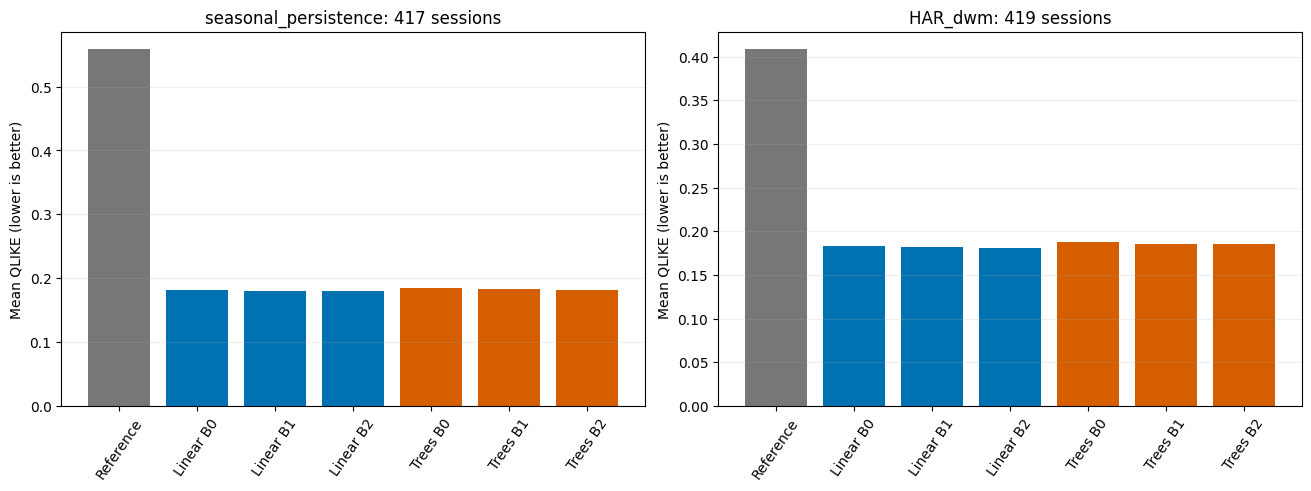

Reference contrasts, RV15; difference = reference − model:


,reference,family,set,N_sessions,reference_qlike,model_qlike,estimate,ci_low,ci_high,p_raw
0,seasonal_persistence,log_ridge_harq,B0,417,0.557917,0.182054,0.375863,0.338188,0.415956,0.000100
1,seasonal_persistence,log_ridge_harq,B1,417,0.557917,0.180591,0.377326,0.339412,0.417769,0.000100
2,seasonal_persistence,log_ridge_harq,B2,417,0.557917,0.179471,0.378446,0.340552,0.418661,0.000100
3,seasonal_persistence,lightgbm_qlike,B0,417,0.557917,0.184349,0.373568,0.336114,0.413360,0.000100
4,seasonal_persistence,lightgbm_qlike,B1,417,0.557917,0.182467,0.375450,0.337845,0.415463,0.000100
5,seasonal_persistence,lightgbm_qlike,B2,417,0.557917,0.181889,0.376028,0.338149,0.416185,0.000100
6,HAR_dwm,log_ridge_harq,B0,419,0.408061,0.183660,0.224400,0.186418,0.283476,0.000100
7,HAR_dwm,log_ridge_harq,B1,419,0.408061,0.182044,0.226017,0.187504,0.286188,0.000100
8,HAR_dwm,log_ridge_harq,B2,419,0.408061,0.180910,0.227150,0.188542,0.287244,0.000100
9,HAR_dwm,lightgbm_qlike,B0,419,0.408061,0.187750,0.220310,0.185181,0.274063,0.000100


Reference contrasts, RV30; difference = reference − model:


,reference,family,set,N_sessions,reference_qlike,model_qlike,estimate,ci_low,ci_high,p_raw
12,seasonal_persistence,log_ridge_harq,B0,417,0.406483,0.146321,0.260162,0.230430,0.292198,0.000100
13,seasonal_persistence,log_ridge_harq,B1,417,0.406483,0.143900,0.262583,0.232566,0.295027,0.000100
14,seasonal_persistence,log_ridge_harq,B2,417,0.406483,0.143093,0.263390,0.233252,0.295677,0.000100
15,seasonal_persistence,lightgbm_qlike,B0,417,0.406483,0.146775,0.259708,0.229752,0.291660,0.000100
16,seasonal_persistence,lightgbm_qlike,B1,417,0.406483,0.143887,0.262596,0.232787,0.294519,0.000100
17,seasonal_persistence,lightgbm_qlike,B2,417,0.406483,0.143522,0.262961,0.233176,0.294791,0.000100
18,HAR_dwm,log_ridge_harq,B0,419,0.339623,0.147307,0.192316,0.160141,0.240612,0.000100
19,HAR_dwm,log_ridge_harq,B1,419,0.339623,0.144760,0.194863,0.161913,0.244792,0.000100
20,HAR_dwm,log_ridge_harq,B2,419,0.339623,0.143957,0.195666,0.162883,0.245438,0.000100
21,HAR_dwm,lightgbm_qlike,B0,419,0.339623,0.149317,0.190306,0.160043,0.234768,0.000100


,family,set,metric,N_sessions,error × 10⁶,CI low × 10⁶,CI high × 10⁶
0,log_ridge_harq,B0,MAE,419,4.6812,3.5029,6.5898
1,log_ridge_harq,B0,RMSE,419,33.6418,8.5500,56.7060
2,log_ridge_harq,B1,MAE,419,4.7196,3.5023,6.6947
3,log_ridge_harq,B1,RMSE,419,33.5516,8.5570,56.5531
4,log_ridge_harq,B2,MAE,419,4.6911,3.4978,6.6293
5,log_ridge_harq,B2,RMSE,419,33.5190,8.5172,56.5167
6,lightgbm_qlike,B0,MAE,419,4.7374,3.4727,6.8170
7,lightgbm_qlike,B0,RMSE,419,34.7724,8.8382,58.6048
8,lightgbm_qlike,B1,MAE,419,4.7705,3.4666,6.9217
9,lightgbm_qlike,B1,RMSE,419,34.8570,8.8279,58.7401


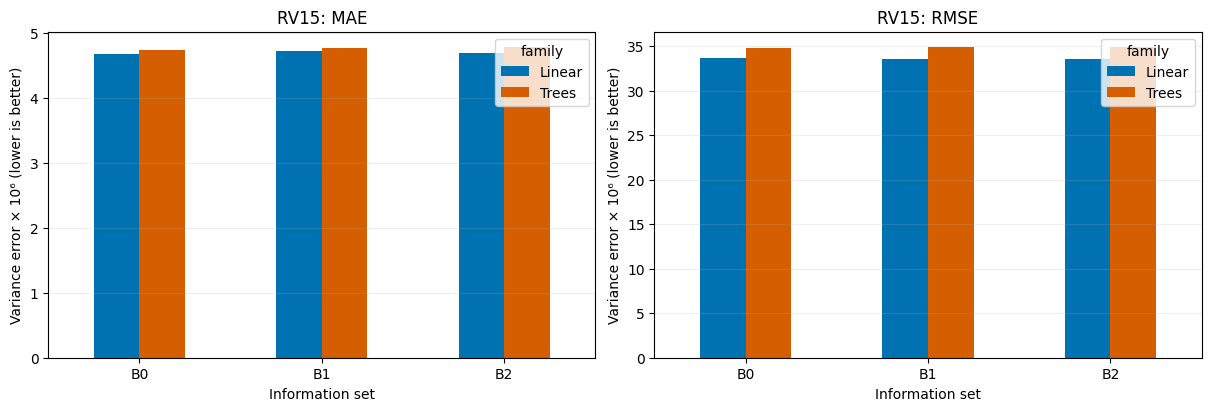

Linear, MAE: B1=4.71957487e-06; B2=4.69114355e-06; B2/B1 descriptive reduction=+0.602 %.
Linear, RMSE: B1=3.35516459e-05; B2=3.35190183e-05; B2/B1 descriptive reduction=+0.097 %.
Trees, MAE: B1=4.77047347e-06; B2=4.78031957e-06; B2/B1 descriptive reduction=-0.206 %.
Trees, RMSE: B1=3.48570093e-05; B2=3.48762896e-05; B2/B1 descriptive reduction=-0.055 %.


In [4]:
# @title Step 4: Reference models and complementary errors
# Read all rows in the public reference tables.
reference_qlike = read_public_csv('artifacts/rp4_robustness_public_v1/reference_qlike.csv')
reference_contrasts = read_public_csv('artifacts/rp4_robustness_public_v1/reference_contrasts.csv')
secondary_metrics = read_public_csv('artifacts/rp4_robustness_public_v1/secondary_metrics.csv')
assert [len(reference_qlike),len(reference_contrasts),len(secondary_metrics)] == [4,24,72]
assert set(reference_contrasts.role) == {'POST_PRIMARY_NOMINAL_ROBUSTNESS'}
assert set(secondary_metrics.role) == {'DESCRIPTIVE_NO_TEST'}
# Match each contrast to its reference horizon and sample.
matched = reference_contrasts.merge(reference_qlike[['horizon','reference','N_origins','N_sessions','estimate']], on=['horizon','reference'], suffixes=('','_reference'), validate='many_to_one')
assert (matched.N_sessions == matched.N_sessions_reference).all()
assert (matched.N_origins == matched.N_origins_reference).all()
assert ((matched.reference_qlike - matched.estimate_reference).abs() < 1e-12).all()
assert ((reference_contrasts.reference_qlike-reference_contrasts.model_qlike-reference_contrasts.estimate).abs() < 1e-12).all()
# Display all reference levels and their coverage.
display(reference_qlike[['horizon','reference','N_origins','N_excluded','N_sessions','estimate','ci_low','ci_high']].style.format({'estimate':'{:.6f}','ci_low':'{:.6f}','ci_high':'{:.6f}'}))
# Use each reference's matched sample; lower bars mean lower QLIKE.
fig, axes = plt.subplots(1,2,figsize=(13,4.8),layout='constrained')
for ax, reference in zip(axes, ['seasonal_persistence','HAR_dwm']):
    part=reference_contrasts[(reference_contrasts.horizon==15)&(reference_contrasts.reference==reference)]
    assert len(part)==6
    labels=['Reference']+[families[r.family]+' '+r.set for r in part.itertuples()]
    values=[part.reference_qlike.iloc[0]]+part.model_qlike.tolist()
    ax.bar(labels,values,color=['#777777']+['#0072B2' if f=='log_ridge_harq' else '#D55E00' for f in part.family])
    ax.set(title=f'{reference}: {int(part.N_sessions.iloc[0])} sessions',ylabel='Mean QLIKE (lower is better)')
    ax.tick_params(axis='x',rotation=55)
    ax.grid(axis='y',alpha=.2)
plt.show()
# Display all 24 reference contrasts, grouped by horizon.
for horizon in sorted(reference_contrasts.horizon.unique()):
    print(f'Reference contrasts, RV{horizon}; difference = reference − model:')
    cols=['reference','family','set','N_sessions','reference_qlike','model_qlike','estimate','ci_low','ci_high','p_raw']
    display(reference_contrasts.loc[reference_contrasts.horizon==horizon,cols].style.format({c:'{:.6f}' for c in ['reference_qlike','model_qlike','estimate','ci_low','ci_high','p_raw']}))

# Read the Trees B1 and B2 values on the seasonal-persistence sample.
seasonal_lgb=reference_contrasts[(reference_contrasts.horizon==15)&(reference_contrasts.reference=='seasonal_persistence')&(reference_contrasts.family=='lightgbm_qlike')].set_index('set')

# Record completion after all checks pass.

# Select all RV15 development-window combinations of family, set and metric.
metric_rows=secondary_metrics[(secondary_metrics.horizon==15)&(secondary_metrics.window=='primary')].copy()
assert len(metric_rows)==12
# Scale variance errors by one million for display.
metric_rows['error × 10⁶']=metric_rows.estimate*1e6
metric_rows['CI low × 10⁶']=metric_rows.ci_low*1e6
metric_rows['CI high × 10⁶']=metric_rows.ci_high*1e6
display(metric_rows[['family','set','metric','N_sessions','error × 10⁶','CI low × 10⁶','CI high × 10⁶']].style.format({c:'{:.4f}' for c in ['error × 10⁶','CI low × 10⁶','CI high × 10⁶']}))
# Plot MAE and RMSE separately because their scales differ.
fig,axes=plt.subplots(1,2,figsize=(12,4),layout='constrained')
for ax,metric in zip(axes,['MAE','RMSE']):
    table=metric_rows[metric_rows.metric==metric].pivot(index='set',columns='family',values='error × 10⁶').rename(columns=families)
    table[['Linear','Trees']].plot.bar(ax=ax,rot=0,color=['#0072B2','#D55E00'])
    ax.set(title=f'RV15: {metric}',ylabel='Variance error × 10⁶ (lower is better)',xlabel='Information set')
    ax.grid(axis='y',alpha=.2)
plt.show()
# Calculate the B2/B1 percentage change for each family and metric.
for family,label in families.items():
    for metric in ['MAE','RMSE']:
        values=metric_rows[(metric_rows.family==family)&(metric_rows.metric==metric)].set_index('set').estimate
        change=100*(values['B1']-values['B2'])/values['B1']
        print(f'{label}, {metric}: B1={values["B1"]:.9g}; B2={values["B2"]:.9g}; B2/B1 descriptive reduction={change:+.3f} %.')

# Record completion after all checks pass.

# Record that this step completed.
EXECUTED_CELLS.append('step_04_reference_models_and_complementary_errors')


### Reading

HAR d/w/m has mean QLIKE 0.408061 at 15 minutes. Seasonal persistence uses 417 sessions, whereas HAR uses 419; each comparison belongs to its own mask. Table 11 and Figure 12 provide this context for the nested contrasts in Table 7.

Linear B2 slightly reduces MAE and RMSE relative to B1; Trees B2 raises both. These are descriptive complementary errors, with saved intervals rather than additional primary tests. Table 12 gives the original units; Figure 13 uses the scaled display.


## Step 5: Claims ledger

Each report value below is transcribed from the PDF. The comparison column distinguishes paired-loss calculations from saved statistics read from verified files. Tolerances are absolute: 0.0005 percentage points for three-decimal reductions, 1e-6 QLIKE, and exact equality for counts and decision states. Probabilities use 0.00005 to match four-decimal printing. Other rounded percentages use half their printed unit, shown on each row. Complementary errors use their printed precision in realised-variance units. Any mismatch stops the notebook.

The checks cover Tables 7, 11, 12 and 13.


In [5]:
# @title Claims ledger
# Fixed values transcribed from the report; never replace them with source-file values.
REPORT_CLAIMS = [{'report_location': 'Table 7', 'claim': 'Linear H1: estimate', 'report_literal': '+0.001616', 'report_value': 0.001616, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'contrast': 'B1_over_B0'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Linear H1: ci_low', 'report_literal': '+0.000253', 'report_value': 0.000253, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'contrast': 'B1_over_B0'}, 'column': 'ci_low', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Linear H1: ci_high', 'report_literal': '+0.003454', 'report_value': 0.003454, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'contrast': 'B1_over_B0'}, 'column': 'ci_high', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Linear H1: percent_reduction_mean', 'report_literal': '+0.880', 'report_value': 0.88, 'unit': 'percentage points', 'tolerance': 0.0005, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'contrast': 'B1_over_B0'}, 'column': 'percent_reduction_mean', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Linear H1: p_raw', 'report_literal': '0.0390', 'report_value': 0.039, 'unit': 'probability', 'tolerance': 5e-05, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'contrast': 'B1_over_B0'}, 'column': 'p_raw', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Linear H1: decision', 'report_literal': 'Reject null', 'report_value': 'Reject null', 'unit': 'status', 'tolerance': 0, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'contrast': 'B1_over_B0'}, 'column': 'hypothesis_status', 'operation': 'status_label'}, {'report_location': 'Table 7', 'claim': 'Linear H2: estimate', 'report_literal': '+0.001134', 'report_value': 0.001134, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'contrast': 'B2_over_B1'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Linear H2: ci_low', 'report_literal': '+0.000335', 'report_value': 0.000335, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'contrast': 'B2_over_B1'}, 'column': 'ci_low', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Linear H2: ci_high', 'report_literal': '+0.001932', 'report_value': 0.001932, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'contrast': 'B2_over_B1'}, 'column': 'ci_high', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Linear H2: percent_reduction_mean', 'report_literal': '+0.623', 'report_value': 0.623, 'unit': 'percentage points', 'tolerance': 0.0005, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'contrast': 'B2_over_B1'}, 'column': 'percent_reduction_mean', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Linear H2: p_raw', 'report_literal': '0.0032', 'report_value': 0.0032, 'unit': 'probability', 'tolerance': 5e-05, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'contrast': 'B2_over_B1'}, 'column': 'p_raw', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Linear H2: decision', 'report_literal': 'Reject null', 'report_value': 'Reject null', 'unit': 'status', 'tolerance': 0, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'contrast': 'B2_over_B1'}, 'column': 'hypothesis_status', 'operation': 'status_label'}, {'report_location': 'Table 7', 'claim': 'Trees H1: estimate', 'report_literal': '+0.002197', 'report_value': 0.002197, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'contrast': 'B1_over_B0'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Trees H1: ci_low', 'report_literal': '+0.000611', 'report_value': 0.000611, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'contrast': 'B1_over_B0'}, 'column': 'ci_low', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Trees H1: ci_high', 'report_literal': '+0.004103', 'report_value': 0.004103, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'contrast': 'B1_over_B0'}, 'column': 'ci_high', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Trees H1: percent_reduction_mean', 'report_literal': '+1.170', 'report_value': 1.17, 'unit': 'percentage points', 'tolerance': 0.0005, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'contrast': 'B1_over_B0'}, 'column': 'percent_reduction_mean', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Trees H1: p_raw', 'report_literal': '0.0135', 'report_value': 0.0135, 'unit': 'probability', 'tolerance': 5e-05, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'contrast': 'B1_over_B0'}, 'column': 'p_raw', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Trees H1: decision', 'report_literal': 'Reject null', 'report_value': 'Reject null', 'unit': 'status', 'tolerance': 0, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'contrast': 'B1_over_B0'}, 'column': 'hypothesis_status', 'operation': 'status_label'}, {'report_location': 'Table 7', 'claim': 'Trees H2: estimate', 'report_literal': '-0.000213', 'report_value': -0.000213, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'contrast': 'B2_over_B1'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Trees H2: ci_low', 'report_literal': '-0.002044', 'report_value': -0.002044, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'contrast': 'B2_over_B1'}, 'column': 'ci_low', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Trees H2: ci_high', 'report_literal': '+0.001104', 'report_value': 0.001104, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'contrast': 'B2_over_B1'}, 'column': 'ci_high', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Trees H2: percent_reduction_mean', 'report_literal': '-0.115', 'report_value': -0.115, 'unit': 'percentage points', 'tolerance': 0.0005, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'contrast': 'B2_over_B1'}, 'column': 'percent_reduction_mean', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Trees H2: p_raw', 'report_literal': '0.6280', 'report_value': 0.628, 'unit': 'probability', 'tolerance': 5e-05, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'contrast': 'B2_over_B1'}, 'column': 'p_raw', 'operation': None}, {'report_location': 'Table 7', 'claim': 'Trees H2: decision', 'report_literal': 'Do not reject', 'report_value': 'Do not reject', 'unit': 'status', 'tolerance': 0, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'contrast': 'B2_over_B1'}, 'column': 'hypothesis_status', 'operation': 'status_label'}, {'report_location': 'Table 13', 'claim': 'Linear H1: estimate', 'report_literal': '+0.000416', 'report_value': 0.000416, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'log_ridge_harq', 'contrast': 'B1_over_B0'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Linear H1: ci_low', 'report_literal': '-0.002209', 'report_value': -0.002209, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'log_ridge_harq', 'contrast': 'B1_over_B0'}, 'column': 'ci_low', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Linear H1: ci_high', 'report_literal': '+0.002878', 'report_value': 0.002878, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'log_ridge_harq', 'contrast': 'B1_over_B0'}, 'column': 'ci_high', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Linear H1: percent_reduction_mean', 'report_literal': '+0.174', 'report_value': 0.174, 'unit': 'percentage points', 'tolerance': 0.0005, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'log_ridge_harq', 'contrast': 'B1_over_B0'}, 'column': 'percent_reduction_mean', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Linear H1: p_raw', 'report_literal': '0.3908', 'report_value': 0.3908, 'unit': 'probability', 'tolerance': 5e-05, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'log_ridge_harq', 'contrast': 'B1_over_B0'}, 'column': 'p_raw', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Linear H1: decision', 'report_literal': 'Do not reject', 'report_value': 'Do not reject', 'unit': 'status', 'tolerance': 0, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'log_ridge_harq', 'contrast': 'B1_over_B0'}, 'column': 'hypothesis_status', 'operation': 'status_label'}, {'report_location': 'Table 13', 'claim': 'Linear H2: estimate', 'report_literal': '+0.004767', 'report_value': 0.004767, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'log_ridge_harq', 'contrast': 'B2_over_B1'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Linear H2: ci_low', 'report_literal': '-0.001109', 'report_value': -0.001109, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'log_ridge_harq', 'contrast': 'B2_over_B1'}, 'column': 'ci_low', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Linear H2: ci_high', 'report_literal': '+0.014742', 'report_value': 0.014742, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'log_ridge_harq', 'contrast': 'B2_over_B1'}, 'column': 'ci_high', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Linear H2: percent_reduction_mean', 'report_literal': '+1.997', 'report_value': 1.997, 'unit': 'percentage points', 'tolerance': 0.0005, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'log_ridge_harq', 'contrast': 'B2_over_B1'}, 'column': 'percent_reduction_mean', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Linear H2: p_raw', 'report_literal': '0.1758', 'report_value': 0.1758, 'unit': 'probability', 'tolerance': 5e-05, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'log_ridge_harq', 'contrast': 'B2_over_B1'}, 'column': 'p_raw', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Linear H2: decision', 'report_literal': 'Gate closed', 'report_value': 'Gate closed', 'unit': 'status', 'tolerance': 0, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'log_ridge_harq', 'contrast': 'B2_over_B1'}, 'column': 'hypothesis_status', 'operation': 'status_label'}, {'report_location': 'Table 13', 'claim': 'Trees H1: estimate', 'report_literal': '+0.007482', 'report_value': 0.007482, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'lightgbm_qlike', 'contrast': 'B1_over_B0'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Trees H1: ci_low', 'report_literal': '+0.001644', 'report_value': 0.001644, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'lightgbm_qlike', 'contrast': 'B1_over_B0'}, 'column': 'ci_low', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Trees H1: ci_high', 'report_literal': '+0.016807', 'report_value': 0.016807, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'lightgbm_qlike', 'contrast': 'B1_over_B0'}, 'column': 'ci_high', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Trees H1: percent_reduction_mean', 'report_literal': '+3.163', 'report_value': 3.163, 'unit': 'percentage points', 'tolerance': 0.0005, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'lightgbm_qlike', 'contrast': 'B1_over_B0'}, 'column': 'percent_reduction_mean', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Trees H1: p_raw', 'report_literal': '0.0568', 'report_value': 0.0568, 'unit': 'probability', 'tolerance': 5e-05, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'lightgbm_qlike', 'contrast': 'B1_over_B0'}, 'column': 'p_raw', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Trees H1: decision', 'report_literal': 'Do not reject', 'report_value': 'Do not reject', 'unit': 'status', 'tolerance': 0, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'lightgbm_qlike', 'contrast': 'B1_over_B0'}, 'column': 'hypothesis_status', 'operation': 'status_label'}, {'report_location': 'Table 13', 'claim': 'Trees H2: estimate', 'report_literal': '-0.002272', 'report_value': -0.002272, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'lightgbm_qlike', 'contrast': 'B2_over_B1'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Trees H2: ci_low', 'report_literal': '-0.009072', 'report_value': -0.009072, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'lightgbm_qlike', 'contrast': 'B2_over_B1'}, 'column': 'ci_low', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Trees H2: ci_high', 'report_literal': '+0.002195', 'report_value': 0.002195, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'lightgbm_qlike', 'contrast': 'B2_over_B1'}, 'column': 'ci_high', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Trees H2: percent_reduction_mean', 'report_literal': '-0.992', 'report_value': -0.992, 'unit': 'percentage points', 'tolerance': 0.0005, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'lightgbm_qlike', 'contrast': 'B2_over_B1'}, 'column': 'percent_reduction_mean', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Trees H2: p_raw', 'report_literal': '0.7554', 'report_value': 0.7554, 'unit': 'probability', 'tolerance': 5e-05, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'lightgbm_qlike', 'contrast': 'B2_over_B1'}, 'column': 'p_raw', 'operation': None}, {'report_location': 'Table 13', 'claim': 'Trees H2: decision', 'report_literal': 'Gate closed', 'report_value': 'Gate closed', 'unit': 'status', 'tolerance': 0, 'source': 'artifacts/rp4_v4_b4/primary_statistics.csv', 'filter': {'horizon_minutes': 15, 'window': 'confirmation', 'family': 'lightgbm_qlike', 'contrast': 'B2_over_B1'}, 'column': 'hypothesis_status', 'operation': 'status_label'}, {'report_location': 'Table 11', 'claim': 'Seasonal persistence: N_sessions', 'report_literal': '417', 'report_value': 417.0, 'unit': 'count', 'tolerance': 0, 'source': 'artifacts/rp4_robustness_public_v1/reference_contrasts.csv', 'filter': {'horizon': 15, 'reference': 'seasonal_persistence', 'family': 'log_ridge_harq', 'set': 'B0'}, 'column': 'N_sessions', 'operation': None}, {'report_location': 'Table 11', 'claim': 'Seasonal persistence: N_origins', 'report_literal': '159,054', 'report_value': 159054.0, 'unit': 'count', 'tolerance': 0, 'source': 'artifacts/rp4_robustness_public_v1/reference_contrasts.csv', 'filter': {'horizon': 15, 'reference': 'seasonal_persistence', 'family': 'log_ridge_harq', 'set': 'B0'}, 'column': 'N_origins', 'operation': None}, {'report_location': 'Table 11', 'claim': 'Seasonal persistence: reference_qlike', 'report_literal': '0.557917', 'report_value': 0.557917, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_robustness_public_v1/reference_contrasts.csv', 'filter': {'horizon': 15, 'reference': 'seasonal_persistence', 'family': 'log_ridge_harq', 'set': 'B0'}, 'column': 'reference_qlike', 'operation': None}, {'report_location': 'Table 11', 'claim': 'Seasonal persistence: model_qlike', 'report_literal': '0.182054', 'report_value': 0.182054, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_robustness_public_v1/reference_contrasts.csv', 'filter': {'horizon': 15, 'reference': 'seasonal_persistence', 'family': 'log_ridge_harq', 'set': 'B0'}, 'column': 'model_qlike', 'operation': None}, {'report_location': 'Table 11', 'claim': 'Seasonal persistence: p_raw', 'report_literal': '0.0001', 'report_value': 0.0001, 'unit': 'probability', 'tolerance': 5e-05, 'source': 'artifacts/rp4_robustness_public_v1/reference_contrasts.csv', 'filter': {'horizon': 15, 'reference': 'seasonal_persistence', 'family': 'log_ridge_harq', 'set': 'B0'}, 'column': 'p_raw', 'operation': None}, {'report_location': 'Table 11', 'claim': 'HAR d/w/m: N_sessions', 'report_literal': '419', 'report_value': 419.0, 'unit': 'count', 'tolerance': 0, 'source': 'artifacts/rp4_robustness_public_v1/reference_contrasts.csv', 'filter': {'horizon': 15, 'reference': 'HAR_dwm', 'family': 'log_ridge_harq', 'set': 'B0'}, 'column': 'N_sessions', 'operation': None}, {'report_location': 'Table 11', 'claim': 'HAR d/w/m: N_origins', 'report_literal': '160,832', 'report_value': 160832.0, 'unit': 'count', 'tolerance': 0, 'source': 'artifacts/rp4_robustness_public_v1/reference_contrasts.csv', 'filter': {'horizon': 15, 'reference': 'HAR_dwm', 'family': 'log_ridge_harq', 'set': 'B0'}, 'column': 'N_origins', 'operation': None}, {'report_location': 'Table 11', 'claim': 'HAR d/w/m: reference_qlike', 'report_literal': '0.408061', 'report_value': 0.408061, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_robustness_public_v1/reference_contrasts.csv', 'filter': {'horizon': 15, 'reference': 'HAR_dwm', 'family': 'log_ridge_harq', 'set': 'B0'}, 'column': 'reference_qlike', 'operation': None}, {'report_location': 'Table 11', 'claim': 'HAR d/w/m: model_qlike', 'report_literal': '0.183660', 'report_value': 0.18366, 'unit': 'QLIKE', 'tolerance': 1e-06, 'source': 'artifacts/rp4_robustness_public_v1/reference_contrasts.csv', 'filter': {'horizon': 15, 'reference': 'HAR_dwm', 'family': 'log_ridge_harq', 'set': 'B0'}, 'column': 'model_qlike', 'operation': None}, {'report_location': 'Table 11', 'claim': 'HAR d/w/m: p_raw', 'report_literal': '0.0001', 'report_value': 0.0001, 'unit': 'probability', 'tolerance': 5e-05, 'source': 'artifacts/rp4_robustness_public_v1/reference_contrasts.csv', 'filter': {'horizon': 15, 'reference': 'HAR_dwm', 'family': 'log_ridge_harq', 'set': 'B0'}, 'column': 'p_raw', 'operation': None}, {'report_location': 'Table 12', 'claim': 'Linear B0: MAE', 'report_literal': '4.68118e-6', 'report_value': 4.68118e-06, 'unit': 'variance', 'tolerance': 5e-11, 'source': 'artifacts/rp4_robustness_public_v1/secondary_metrics.csv', 'filter': {'horizon': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'set': 'B0', 'metric': 'MAE'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 12', 'claim': 'Linear B0: RMSE', 'report_literal': '3.36418e-5', 'report_value': 3.36418e-05, 'unit': 'variance', 'tolerance': 5e-11, 'source': 'artifacts/rp4_robustness_public_v1/secondary_metrics.csv', 'filter': {'horizon': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'set': 'B0', 'metric': 'RMSE'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 12', 'claim': 'Linear B1: MAE', 'report_literal': '4.71957e-6', 'report_value': 4.71957e-06, 'unit': 'variance', 'tolerance': 5e-11, 'source': 'artifacts/rp4_robustness_public_v1/secondary_metrics.csv', 'filter': {'horizon': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'set': 'B1', 'metric': 'MAE'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 12', 'claim': 'Linear B1: RMSE', 'report_literal': '3.35516e-5', 'report_value': 3.35516e-05, 'unit': 'variance', 'tolerance': 5e-11, 'source': 'artifacts/rp4_robustness_public_v1/secondary_metrics.csv', 'filter': {'horizon': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'set': 'B1', 'metric': 'RMSE'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 12', 'claim': 'Linear B2: MAE', 'report_literal': '4.69114e-6', 'report_value': 4.69114e-06, 'unit': 'variance', 'tolerance': 5e-11, 'source': 'artifacts/rp4_robustness_public_v1/secondary_metrics.csv', 'filter': {'horizon': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'set': 'B2', 'metric': 'MAE'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 12', 'claim': 'Linear B2: RMSE', 'report_literal': '3.35190e-5', 'report_value': 3.3519e-05, 'unit': 'variance', 'tolerance': 5e-11, 'source': 'artifacts/rp4_robustness_public_v1/secondary_metrics.csv', 'filter': {'horizon': 15, 'window': 'primary', 'family': 'log_ridge_harq', 'set': 'B2', 'metric': 'RMSE'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 12', 'claim': 'Trees B0: MAE', 'report_literal': '4.73740e-6', 'report_value': 4.7374e-06, 'unit': 'variance', 'tolerance': 5e-11, 'source': 'artifacts/rp4_robustness_public_v1/secondary_metrics.csv', 'filter': {'horizon': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'set': 'B0', 'metric': 'MAE'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 12', 'claim': 'Trees B0: RMSE', 'report_literal': '3.47724e-5', 'report_value': 3.47724e-05, 'unit': 'variance', 'tolerance': 5e-11, 'source': 'artifacts/rp4_robustness_public_v1/secondary_metrics.csv', 'filter': {'horizon': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'set': 'B0', 'metric': 'RMSE'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 12', 'claim': 'Trees B1: MAE', 'report_literal': '4.77047e-6', 'report_value': 4.77047e-06, 'unit': 'variance', 'tolerance': 5e-11, 'source': 'artifacts/rp4_robustness_public_v1/secondary_metrics.csv', 'filter': {'horizon': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'set': 'B1', 'metric': 'MAE'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 12', 'claim': 'Trees B1: RMSE', 'report_literal': '3.48570e-5', 'report_value': 3.4857e-05, 'unit': 'variance', 'tolerance': 5e-11, 'source': 'artifacts/rp4_robustness_public_v1/secondary_metrics.csv', 'filter': {'horizon': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'set': 'B1', 'metric': 'RMSE'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 12', 'claim': 'Trees B2: MAE', 'report_literal': '4.78032e-6', 'report_value': 4.78032e-06, 'unit': 'variance', 'tolerance': 5e-11, 'source': 'artifacts/rp4_robustness_public_v1/secondary_metrics.csv', 'filter': {'horizon': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'set': 'B2', 'metric': 'MAE'}, 'column': 'estimate', 'operation': None}, {'report_location': 'Table 12', 'claim': 'Trees B2: RMSE', 'report_literal': '3.48763e-5', 'report_value': 3.48763e-05, 'unit': 'variance', 'tolerance': 5e-11, 'source': 'artifacts/rp4_robustness_public_v1/secondary_metrics.csv', 'filter': {'horizon': 15, 'window': 'primary', 'family': 'lightgbm_qlike', 'set': 'B2', 'metric': 'RMSE'}, 'column': 'estimate', 'operation': None}]

def build_claims_ledger(report_claims, read_public_csv, fetch_bytes, checks, quick=False):
    """Compare fixed report values with verified files and the calculated primary contrasts."""
    import html
    import json
    import math
    import numpy as np
    import pandas as pd
    from IPython.display import HTML, display

    primary_path = 'artifacts/rp4_v4_b4/primary_statistics.csv'
    summary_path = 'artifacts/rp4_v4_b2_rv15/summary.json'
    primary = read_public_csv(primary_path)
    cache = {primary_path: primary}

    def read_rows(source):
        if source not in cache:
            path, _, key = source.partition('#')
            if key:
                value = json.loads(fetch_bytes(path))
                for name in key.split('.'):
                    value = value[name]
                cache[source] = pd.DataFrame(value)
            else:
                cache[source] = read_public_csv(path)
        return cache[source]

    def select(frame, filters):
        chosen = frame
        for name, value in filters.items():
            chosen = chosen.loc[chosen[name].eq(value)]
        return chosen

    def one(frame, filters):
        chosen = select(frame, filters)
        assert len(chosen) == 1, f'Expected one result for {filters}; found {len(chosen)}'
        return chosen.iloc[0]

    def primary_row(horizon, family='log_ridge_harq', contrast='B2_over_B1'):
        return one(primary, {'horizon_minutes': horizon, 'window': 'primary',
                             'family': family, 'contrast': contrast})

    # Check the separately published segment table against its saved summary.
    if not quick:
        segment_rows = read_rows('artifacts/rp4_v4_b4/regime_secondary.csv')
        summary_rows = read_rows(summary_path + '#regime_secondary')
        for row in select(segment_rows, {'horizon_minutes': 15, 'window': 'primary',
                                         'statistic': 'mean'}).itertuples():
            if row.subset not in ('first_hour', 'last_hour'):
                continue
            saved = one(summary_rows, {'subset': row.subset, 'family': row.family,
                                       'contrast': row.contrast, 'statistic': 'mean'})
            for name in ('estimate', 'ci_low', 'ci_high', 'p_raw', 'p_holm'):
                assert abs(float(saved[name]) - float(getattr(row, name))) <= 1e-12

    results = []
    selected_claims = [c for c in report_claims
                       if c['source'] != 'NOT_IN_12_CSV'
                       and (not quick or c['report_location'] in
                            ('Table 7', 'Table 11', 'Table 12', 'Table 13'))]
    assert selected_claims, 'The claims list is empty.'
    for claim in selected_claims:
        filters = dict(claim['filter'])
        operation = claim.get('operation')
        source = claim['source']
        column = claim['column']
        basis = 'Saved statistic verified'
        if claim['report_location'] == 'Table 7' and column in ('estimate', 'percent_reduction_mean'):
            row = one(checks, {'family': filters['family'], 'contrast': filters['contrast']})
            actual = float(row['delta_QLIKE' if column == 'estimate' else 'reduction_percent'])
            basis = 'Paired losses recalculated'
        elif operation and operation.startswith('placebo_'):
            horizon = filters['horizon']
            draws = select(read_rows(source), filters)['delta'].to_numpy(dtype=float)
            assert len(draws) == 50 and np.isfinite(draws).all()
            observed = float(primary_row(horizon).estimate)
            operation_name = operation[len('placebo_'):]
            actual = {
                'count': len(draws), 'observed': observed, 'mean': math.fsum(draws) / len(draws),
                'quantile_025': float(np.quantile(draws, .025)),
                'quantile_975': float(np.quantile(draws, .975)),
                'exceedances': int((draws > observed).sum()),
                'ascending_rank': 1 + int((draws < observed).sum()),
                'empirical_p': (1 + int((draws >= observed).sum())) / (len(draws) + 1),
                'retained_percent': 100 * (math.fsum(draws) / len(draws)) / observed,
            }[operation_name]
            basis = 'Saved permutation draws summarised'
        elif claim['report_location'] == 'Table 17' and operation:
            row = one(read_rows(source), filters)
            state_filter = dict(filters, contrast='B1_over_B0')
            state = one(read_rows(source), state_filter)
            baseline = float(primary_row(15, contrast='B1_over_B0').baseline_loss)
            if filters['contrast'] == 'B2_over_B1':
                baseline -= float(state.estimate)
            assert baseline > 0
            actual = 100 * float(row.estimate) / baseline
            basis = 'Saved cutoff difference rescaled'
        elif claim['report_location'] == 'Table 3':
            all_assets = filters.get('asset') == 'All'
            if all_assets:
                filters.pop('asset')
            rows = select(read_rows(source), filters)
            assert len(rows) == (6 if all_assets else 1)
            if column:
                actual = float(rows[column].sum())
            elif source.endswith('#empty_window_secondary.census'):
                actual = 100 * rows.N_empty_origins.sum() / rows.N_origins.sum()
            else:
                actual = 100 * rows.eligible_rows.sum() / rows.scheduled_rows.sum()
            basis = 'Saved census counts aggregated'
        else:
            row = one(read_rows(source), filters)
            actual = row[column]
            if operation == 'status_label':
                actual = {'REJECTED': 'Reject null', 'NOT_REJECTED': 'Do not reject',
                          'NOT_TESTED': 'Gate closed'}[actual]
        expected = claim['report_value']
        tolerance = claim['tolerance']
        if claim['unit'] == 'status':
            matched = actual == expected
            computed = str(actual)
            allowed = 'Exact state'
        else:
            actual = float(actual)
            assert math.isfinite(actual) and math.isfinite(float(expected))
            matched = abs(actual - expected) <= tolerance
            computed = f'{actual:.10g}'
            allowed = f'{tolerance:g} {claim["unit"]}'
        assert matched, f'{claim["report_location"]}, {claim["claim"]}: {actual} differs from {expected}'
        results.append({'Report location': claim['report_location'], 'Claim': claim['claim'],
                        'Report value': claim['report_literal'], 'Recomputed here': computed,
                        'Tolerance': allowed, 'Basis': basis, 'Match': '✔'})
    ledger = pd.DataFrame(results)
    assert len(ledger) == len(selected_claims) and ledger['Match'].eq('✔').all()
    # Group the complete ledger into expandable tables for a compact reading view.
    parts = [f'<p><strong>Claims ledger: {len(ledger)} of {len(ledger)} matched ✔</strong></p>']
    for location, group in ledger.groupby('Report location', sort=False):
        parts.append('<details><summary>' + html.escape(location) + f': {len(group)} matched</summary>'
                     + group.drop(columns='Report location').to_html(index=False, escape=True)
                     + '</details>')
    display(HTML(''.join(parts)))
    return ledger

# Stop on the first mismatch before allowing the receipt to run.
claims_ledger = build_claims_ledger(REPORT_CLAIMS, read_public_csv, fetch_bytes, checks, quick=True)

# Record that this step completed.
EXECUTED_CELLS.append('step_05_claims_ledger')


Claim,Report value,Recomputed here,Tolerance,Basis,Match
Linear H1: estimate,+0.001616,0.001616311703,1e-06 QLIKE,Paired losses recalculated,✔
Linear H1: ci_low,+0.000253,0.0002529862672,1e-06 QLIKE,Saved statistic verified,✔
Linear H1: ci_high,+0.003454,0.003453534377,1e-06 QLIKE,Saved statistic verified,✔
Linear H1: percent_reduction_mean,+0.880,0.8800546831,0.0005 percentage points,Paired losses recalculated,✔
Linear H1: p_raw,0.0390,0.039,5e-05 probability,Saved statistic verified,✔
Linear H1: decision,Reject null,Reject null,Exact state,Saved statistic verified,✔
Linear H2: estimate,+0.001134,0.001133759659,1e-06 QLIKE,Paired losses recalculated,✔
Linear H2: ci_low,+0.000335,0.0003350369703,1e-06 QLIKE,Saved statistic verified,✔
Linear H2: ci_high,+0.001932,0.001932161587,1e-06 QLIKE,Saved statistic verified,✔
Linear H2: percent_reduction_mean,+0.623,0.6227940964,0.0005 percentage points,Paired losses recalculated,✔


### Reading

Every checked row must show ✔. A saved probability is verified against the report, while the four Table 7 means and reductions are recalculated from paired session losses. The ledger therefore states which kind of evidence supports each row.


## What this notebook establishes

The headline values in Tables 7, 11, 12 and 13 agree with the published aggregates within the stated tolerances. The input checks fail if any byte changes; the ledger stops if a checked value differs from the report.

## What it cannot establish

Model fitting, predictor construction and point-in-time filters run on licensed minute-level data that cannot be redistributed. Their outputs enter this notebook as saved aggregates. Section 3.10 explains what is retained and how access works. The historical final window does not confirm the full sequence in Table 13.

## Receipt

The final cell checks the exact step order and records the input fingerprints, numerical contrasts and software versions. A completed run shows PASS_PUBLIC_SAVED_RESULTS. It records the verification supporting Table 7 and the Claims ledger.


In [6]:
# @title Receipt
receipt = {'status':'PASS_PUBLIC_SAVED_RESULTS', 'source_commit':SOURCE_COMMIT,
    'public_source_commit':PUBLIC_SOURCE_COMMIT,
    'bundle_sha256':BUNDLE_SHA256, 'input_sha256':PUBLIC_HASHES,
    'sessions':len(losses), 'contrasts_recalculated':checks.to_dict('records'),
    'public_reference_rows':len(reference_qlike),
    'public_reference_contrast_rows':len(reference_contrasts),
    'secondary_metric_rows':len(secondary_metrics), 'new_fits':0,
    'restricted_files_read':0, 'widgets':0,
    'scope':'Public saved-results arithmetic and static figures; no training or new inference',
    'runtime':{'python':sys.version.split()[0], 'pandas':pd.__version__, 'matplotlib':matplotlib.__version__}}

# Require every preceding step, including the ledger, to have completed.
EXECUTED_CELLS.append('step_06_receipt')
assert EXECUTED_CELLS == ['step_01_verify_inputs', 'step_02_the_four_primary_contrasts', 'step_03_the_final_window', 'step_04_reference_models_and_complementary_errors', 'step_05_claims_ledger', 'step_06_receipt']
receipt['executed_code_cells']=len(EXECUTED_CELLS)
receipt['executed_code_cell_ids']=EXECUTED_CELLS.copy()
receipt_json=json.dumps(receipt,indent=2,ensure_ascii=False)
Path('PUBLIC_EXECUTION_RECEIPT.json').write_text(receipt_json,encoding='utf-8')
# Present a short result; retain the complete machine-readable record below.
display(HTML('<h3>Verification complete</h3><p><b>PASS_PUBLIC_SAVED_RESULTS</b></p><p>'+str(len(EXECUTED_CELLS))+' code cells completed; '+str(len(claims_ledger))+' report values matched.</p><details><summary>Complete execution receipt</summary><pre>'+html.escape(receipt_json)+'</pre></details>'))

